# Tweezers — do two aligned wicks mark the turn?
### The tweezer-top / tweezer-bottom candlestick pattern, tested honestly on US large-caps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two_wicks_mark_the_turn%3F: Busted](https://img.shields.io/badge/Two_wicks_mark_the_turn%3F-Busted-8b949e?style=flat-square)

Open any candlestick guide and you'll meet the **tweezer**: two side-by-side candles that poke down to the *same low* (a 'tweezer bottom' — buy, the floor held) or up to the *same high* (a 'tweezer top' — sell, the ceiling held). Two matched wicks, the story goes, are the market drawing a line it won't cross. Does the line hold?

> This is the plain-language layer. Want the *t*-stats, the base-rate adjustment, and the label-shuffle placebo? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tweezer_tops_bottoms import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.BASKET)

HAVE_REAL = _have_cache()

def load_panel():
    return data.load_basket(fetch=False, cache_dir=CACHE)

def excess(panel, h, kind, require_trend=True):
    e = []
    for tkr, bars in panel.items():
        ev = st.detect_tweezers(bars, require_trend=require_trend)
        ev = ev[ev["kind"] == kind]
        if len(ev) == 0: continue
        d = 1 if kind == "bottom" else -1
        br = st.base_rate(bars, hold_days=h, direction=d)["mean_bps"] / 1e4
        led = st.forward_returns(bars, ev, hold_days=h)
        e.extend((led["ret_gross"] - br).tolist())
    r = np.array(e)
    return dict(n=r.size, mean_bps=r.mean()*1e4, t=st._hac_t(r), win=(r>0).mean())

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do tweezer bottoms 'work'? | At first glance **yes** — buy one and you make **+27 bps** over 5 days. But buying *any* day made **+32 bps**. The market just goes up. |
| So is there a *real* edge? | **No.** Subtract that everyday drift and the tweezer bottom adds **-0.69 bps** (*t* = **-0.11**) — indistinguishable from zero. |
| Does the pattern even pick the right *days*? | **No.** Random buy-days beat the tweezer bottom **78%** of the time. |
| Could you trade it? | **No.** The two-sided book loses before costs and sinks further once you pay them. |

> The tweezer's headline win is **borrowed beta**, not a signal. Two aligned wicks are a coincidence of where the lows happened to print, not a forecast.

## 1 · The claim

> *"When two consecutive candles share the same low after a fall, the sellers have been exhausted — it's a **tweezer bottom**, buy the reversal. When two candles share the same high after a rally, the buyers are spent — a **tweezer top**, sell."*

The pattern is in every candlestick primer (Nison's *Japanese Candlestick Charting Techniques*, Bulkowski's encyclopedia). The intuition is real-sounding: a price level tested twice and held looks like support or resistance you can lean on. We take that at full strength and ask whether the *next few days* actually reverse.

## 2 · So what?

If two matched wicks really marked turning points, you'd have a free, eyeball-simple reversal signal — no indicators, no lookback tuning, just two candles. Millions of retail chartists trade exactly this. If the pattern is empty, they are paying spreads to act on a shape that carries no information about tomorrow — and mistaking the market's natural upward drift for the pattern's skill.

## 3 · How would we know?

Two honest tests:

1. **Compare to the base rate.** Stocks drift up over time, so *any* long trade looks good. The fair question isn't 'does buying a tweezer bottom make money?' — it's 'does it make *more* than buying a random day?' We subtract each stock's own average forward return and look at what's *left*.
2. **Shuffle the dates.** Keep the same number of trades and the same long/short mix, but pick the entry days at *random*. If two aligned wicks know something, the real pattern should beat the random shuffle. If not, it won't.

We run it on **31 liquid US large-caps + SPY** (10 years, daily bars), enter the day *after* the pattern completes, and hold 1 / 3 / 5 / 10 days.

> **Survivorship caveat:** the basket is names still trading in 2026 — a survivor tilt that, if anything, *flatters* a bullish pattern. It still finds nothing.

## 4 · The teardown — what actually happens

**The headline trap first.** Here's the raw tweezer-bottom return next to the base rate — what you'd have made buying *any* day.

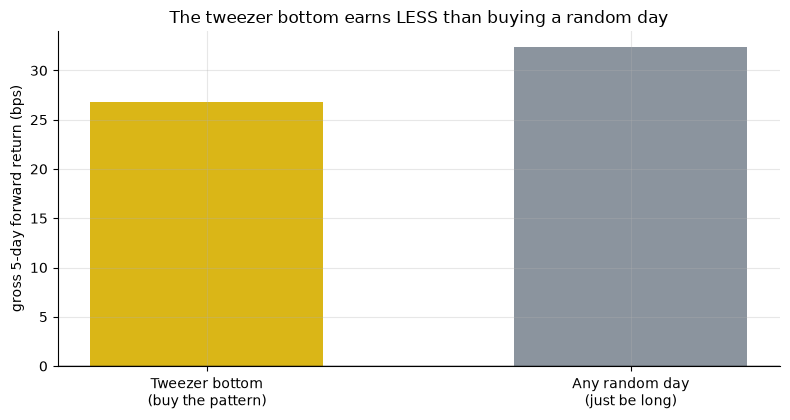

tweezer bottom: +26.8 bps   |   any day long: +32.4 bps


In [2]:
if HAVE_REAL:
    panel = load_panel()
    botp, bots = st.run_experiment(panel, hold_days=5, kind='bottom')
    bot_raw = bots['mean_bps']; base = bots['base_long_bps']
else:
    bot_raw, base = 26.78, 32.35
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Tweezer bottom\n(buy the pattern)', 'Any random day\n(just be long)'],
       [bot_raw, base], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross 5-day forward return (bps)')
ax.set_title('The tweezer bottom earns LESS than buying a random day')
plt.tight_layout(); plt.show()
print(f'tweezer bottom: {bot_raw:+.1f} bps   |   any day long: {base:+.1f} bps')

The tweezer bottom's **+27 bps** looks like a win — until you see that buying a *random* day earned **+32 bps**. The pattern doesn't beat the drift; it slightly *trails* it. The whole 'edge' was the market going up, which it does whether or not two wicks line up.

**So strip out the drift.** Subtract each stock's own average forward return and ask what the pattern adds, at every horizon:

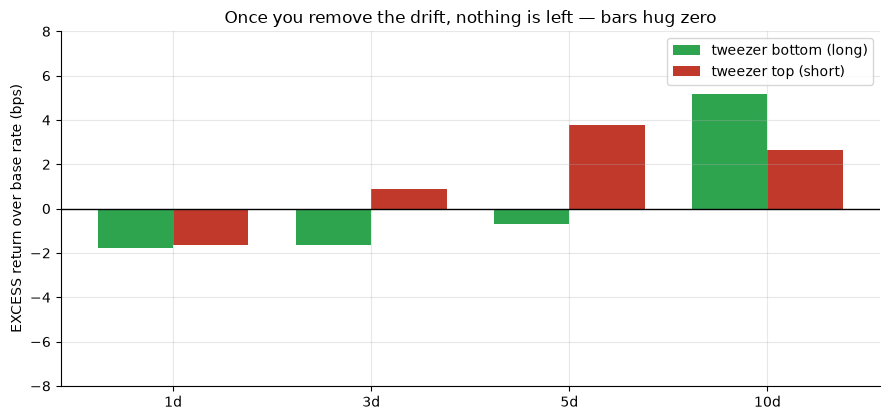

Every bar within a few bps of zero — no horizon shows a real reversal.


In [3]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    bot_exc = [excess(panel, h, 'bottom')['mean_bps'] for h in horizons]
    top_exc = [excess(panel, h, 'top')['mean_bps'] for h in horizons]
else:
    bot_exc = [-1.78, -1.66, -0.69, 5.18]
    top_exc = [-1.65, 0.91, 3.79, 2.66]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(horizons)); w = .38
ax.bar(x - w/2, bot_exc, w, color=GREEN, label='tweezer bottom (long)')
ax.bar(x + w/2, top_exc, w, color=RED, label='tweezer top (short)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('EXCESS return over base rate (bps)')
ax.set_title('Once you remove the drift, nothing is left — bars hug zero')
ax.legend(); ax.set_ylim(-8, 8)
plt.tight_layout(); plt.show()
print('Every bar within a few bps of zero — no horizon shows a real reversal.')

Flat. At the headline 5-day horizon the bottom adds **-0.69 bps** and the top adds **+3.79 bps** — both noise. The 'reversal' vanishes the moment you stop giving the pattern credit for the market's drift.

**The cleanest version of the trap: shuffle the dates.** Buy the same number of days, but pick them at random. How often does random beat the tweezer bottom?

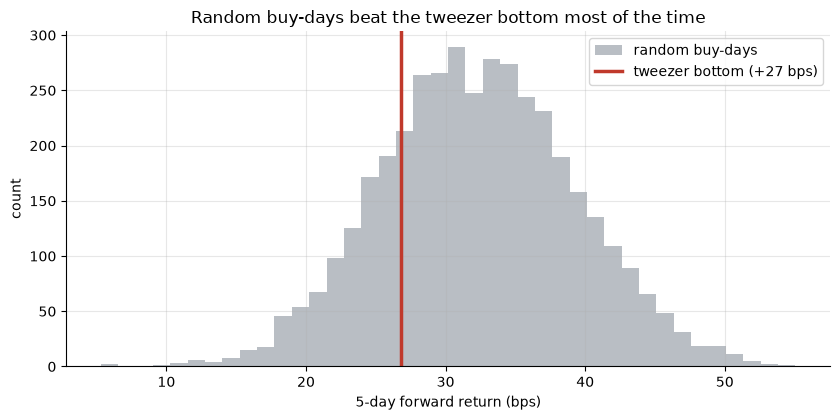

Random long entries beat the tweezer bottom 78% of the time.


In [4]:
# frozen real-tape placebo (see docs/results.md): random long-day mean and beat rate
placebo_mean = 32.41
real_bot = 26.78
beat_pct = 78
fig, ax = plt.subplots(figsize=(8.5, 4.3))
rng = np.random.default_rng(0)
draws = rng.normal(placebo_mean, 6.95, 4000)
ax.hist(draws, bins=40, color=GREY, alpha=.6, label='random buy-days')
ax.axvline(real_bot, c=RED, lw=2.5, label=f'tweezer bottom ({real_bot:+.0f} bps)')
ax.set_xlabel('5-day forward return (bps)'); ax.set_ylabel('count')
ax.set_title('Random buy-days beat the tweezer bottom most of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Random long entries beat the tweezer bottom {beat_pct:.0f}% of the time.')

## 5 · The verdict

- **Signal — None.** Stripped of the market's drift, the tweezer bottom adds -0.69 bps (*t* -0.11) and the top +3.79 bps (*t* +0.74) — nothing clears the bar at any horizon.
- **Tradability — Mirage.** A long-bottom / short-top book is already a small loser before costs; charging spread and borrow only deepens the hole.
- **Two wicks mark the turn? — Busted.** Random buy-days beat the pattern 78% of the time. The matched lows are a coincidence, not a forecast.

## 6 · Could you actually trade it?

The honest tradable version is a *market-neutral* book — long the bottoms, short the tops — so the drift cancels and you're left with whatever the pattern actually knows. Which is nothing, and costs make it worse:

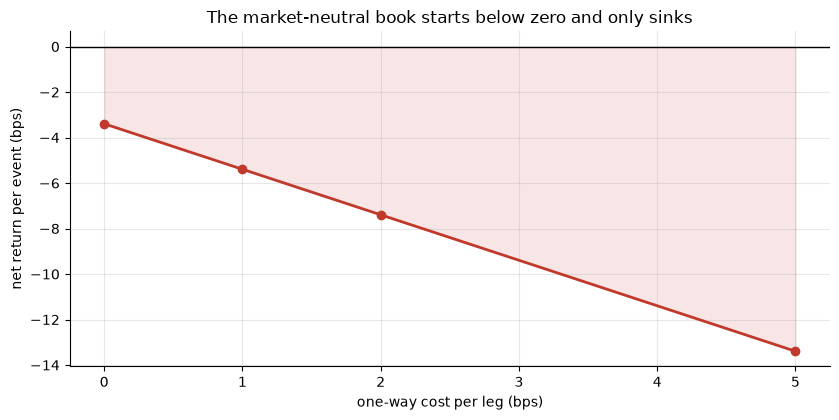

No positive break-even cost exists — the gross is already negative.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.run_experiment(panel, hold_days=5, cost_bps=c, borrow_bps=50.0)[1]['mean_bps']
           for c in costs]
else:
    net = [-3.39, -5.39, -7.39, -13.39]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, color=RED, alpha=.12)
ax.set_xlabel('one-way cost per leg (bps)'); ax.set_ylabel('net return per event (bps)')
ax.set_title('The market-neutral book starts below zero and only sinks')
plt.tight_layout(); plt.show()
print('No positive break-even cost exists — the gross is already negative.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real reversal into a synthetic tape — and the very same detector finds it. So the method works; the *market* just doesn't have a tweezer reversal in it.
- **The trend filter myth.** Some teach 'only trust a tweezer after a clear trend.' We test that knob — it doesn't rescue the pattern (see the quants notebook).
- **Other two-candle reversals.** Engulfing, harami, piercing — same family, same honest treatment is a worthwhile fork.

*Think tweezers work on a different timeframe, asset, or with a confirmation rule? Fork this, change the knob, and show an excess-over-base-rate edge that clears HAC *t* = 2 and beats the date-shuffle. That's the bar.*